**Lab 5: FIR Filtering 2**

The goal of this lab is to study the response of FIR filters to inputs such as complex exponentials and sinusoids. In the experiments of this lab, you will use `np.convolve()` to implement filters and `freqz()` to obtain the filter’s frequency response. As a result, you should learn how to characterize a filter by knowing how it reacts to different frequency components in the input.
This lab also introduces two practical filters: bandpass filters and nulling filters.
Bandpass filters can be used to detect and extract information from complex signals,
e.g., tones in a touch-tone telephone dialer. Nulling filters can be used to remove
sinusoidal interference, e.g., jamming signals in a radar.

In [60]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_frequency_response

1.1. First, let's replicate what we did until now. Copy the functions synthesize and envelope and obtain the synthesis from the last lab.

In [61]:
# Write your code here
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

def envelope(x, N):
    x_rectified = np.abs(x)
    averager = np.ones(N) / N
    y = np.convolve (averager, x_rectified, 'same')
    return y

fs = 44100
filepath = "./sis1_group102/8386__speedy__clean_b_str_pluck.wav"
ref, fs = load_audio(filepath)
N = 750
env = envelope(ref, N)
weights = [1, 0.451, 0.014, 0.011, 0.214, 0.130, 0.023]
phi = np.arccos(-0.0025/0.937) + np.pi
t = np.arange(0, 16.8914965, 1.0/fs)
synthetic = 0.683*env*synthesize(246, phi, weights, t)

1.2 Plot both reference and synthesised signal.

In [62]:
# Write your code here
plot_signals([ref, synthetic], fs, 0, 0.5, name=["real signal", "synthetic signal"])

---

**2. Averaging filter**

Now let's analyze the frequency response of the average filter used in the envelope function. The Scipy Python module has a function called *freqz()* for computing the frequency
response of a discrete-time LTI system. The following Python statements show how to
use freqz to compute and plot both the magnitude (absolute value) and the phase of
the frequency response of a four-point averaging system as a function of ω in the range − π ≤ ω ≤ π :

For FIR filters, the second argument of `freqz(-, 1,- )` must always be equal to 1. The frequency vector ww should cover an interval of length 2π for ω , and its spacing must be fine enough to give a smooth curve for H(ejω) . Note: we will always use capital H for the frequency response.

2.1 Use the `freqz` and `plot_frequency_response` functions to plot the frequency response of the averaging filter of your envelope function.



In [ ]:
# Write your code here
n = 4
w = np.arange(-np.pi, np.pi, np.pi/500)
_, H = signal.freqz([1/n]*n, 1, w)
plot_frequency_response(w, H)


In [50]:
_, H2 = signal.freqz(env, 1, w)
plot_frequency_response(w, H2)

2.2 Looking at the frequency responses, what are the main differences between your filter and the four-point averaging filter. What happens when the value N is increased?

There is a big difference in both the magnitude and phase plots. The magnitude of my FIR filter is defined as a single peak in frequency 0, with magnitude bigger than 8000, whereas in the 4-point averaging filter the magnitude varies in three bubble forms, the biggest magnitude being 1. On the other hand, the phases in the 4-point averaging filter have a negative slope, conversely to the positive slope in my envelope. When N is increased, more bubble forms appear and the filter gets more accurate.

---

**3. Nulling Filters for Rejection**

Nulling filters are filters that completely eliminate some frequency components. If the frequency is $\omega=0$ or $\omega=\pi$ then a two-point FIR filter will do the nulling. The simplest possible general nulling filter can have as few as three coefficients. If $\omega_n$ is the desired nulling frequency, then the following length-3 FIR filter

$$
y[n] = x[n] - 2\cos(\omega_n)x[n-1] + x[n-2] 
$$

will have a zero in its frequency response at $\omega=\omega_n$. For example, a filter designed to completely eliminate signals of the form $e^{j0.5\pi}$ would have the following coefficients because we would pick the desired nulling frequency to be $\omega_n = 0.5\pi$

$$
b_0 = 1, \quad b1=-2cos(\omega_n)=0, \quad b_2=1
$$

3.1 Use the following function to add an interference in your reference signal. Name the corrupted signal as `x_interf`.

In [51]:
def add_interference(x, fs, f):
  # Write your code here
  t = np.linspace(0, len(x)*1/float(fs), len(x))
  x_interf = x + (np.amax(x)/10)*np.sin(2*np.pi*f*t)
  return x_interf

In [52]:
# Write your code here
x_interf = add_interference(synthetic, fs, 1000)

3.2 Plot both the reference signal and the corrupted signal and listen to the latter one. 

In [54]:
# Write your code here
plot_signals([ref, x_interf], fs, 0, 0.5, name=["real signal", "corrupted signal"])

In [57]:
ipd.Audio(x_interf, rate=fs)

3.3 Compare the spectrograms of the reference signal and the interference signal. 

(0.0, 2000.0)

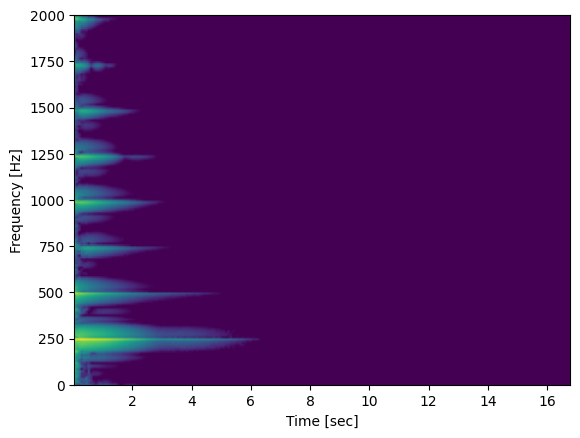

In [ ]:
# Write your code here
f,t,S=spectrogram(ref, fs, nperseg=4096)
plot_spectrogram(f, t, S)
plt.ylim([0,2000])

(0.0, 2000.0)

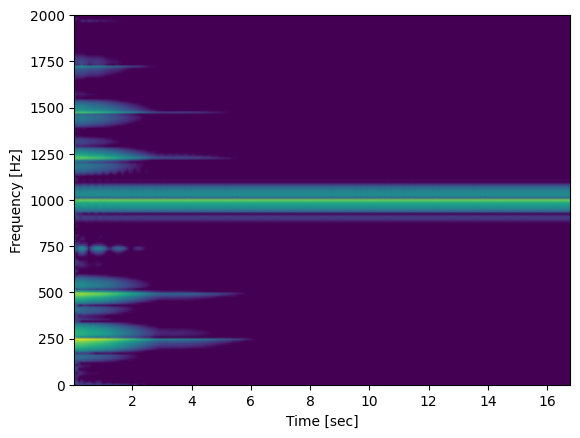

In [66]:
f,t,S=spectrogram(x_interf, fs, nperseg=4096)
plot_spectrogram(f, t, S)
plt.ylim([0,2000])

We can see cleary that the interference is the same as the reference but with the 1000 frequency added.

3.4. Create a function `remove_interference(x, fs)` that applies a nulling filter devised to remove the interference at 1000 Hz. 

Note: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$

In [70]:
def remove_interference(x, fs):
    fn = 1000
    wn = 2*np.pi*fn/fs
    return np.convolve(x, [1, -2*np.cos(wn), 1], "same")

    """Applies nulling filter to remove an interference at 1000 Hz

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    fs : int or float
        Frequency rate in Hz

    Returns
    -------
    y : np.array
        The output of the filter

    """

3.5 Use the `remove_interference` funcion to clean the corrupted signal,  `x_interf`. Call the output as `x_clean`. Compare the spectrograms of both signals. Explain the result.

(0.0, 2000.0)

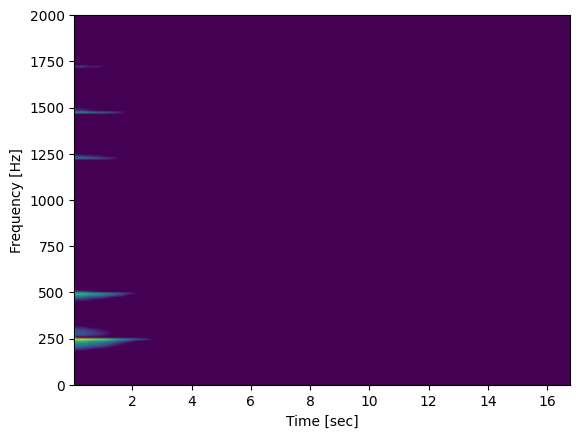

In [73]:
# Write your code here
x_clean = remove_interference(x_interf, fs)
f,t,S=spectrogram(x_clean, fs, nperseg=4096)
plot_spectrogram(f, t, S)
plt.ylim([0,2000])

The main difference between the spectrograms is the duration. While in the reference signal the fundamental frequency (near 250Hz) lasts for 6 seconds, in the cleaned signal the same frequency lasts a little bit more than 2 seconds, the same is applied to all the other frequencies showed in the spectrogram. That also affects the thickness of the frequency representation, as in the cleaned signal the horizontal lines are much slimmer.